In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import rasterio as rio
from rasterio.plot import show

from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MaxNLocator

from sklearn.cluster import AgglomerativeClustering
from libpysal.weights import Voronoi

# (opcional pero recomendado para el matching 1–a–1)
from scipy.optimize import linear_sum_assignment


# ─────────────────────────────────────────────
# Estética global
# ─────────────────────────────────────────────
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def _agglo_kwargs():
    import inspect
    params = inspect.signature(AgglomerativeClustering).parameters
    return {"metric": "euclidean"} if "metric" in params else {"affinity": "euclidean"}


def build_voronoi_connectivity(gdf_points):
    """Conectividad espacial para estaciones (puntos) usando Voronoi (queen)."""
    g = gdf_points
    if g.crs is not None and getattr(g.crs, "is_geographic", False):
        g = g.to_crs(3116)  # solo para conectividad
    coords = np.column_stack([g.geometry.x.values, g.geometry.y.values])
    return Voronoi(coords, criterion="queen").sparse


def fit_agglo_labels(X, connectivity, k=5):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
        connectivity=connectivity,
        **_agglo_kwargs()
    )
    return model.fit_predict(X) + 1  # 1..k


def align_clusters_to_zones(
    gdf_pts,
    gdf_polys,
    zone_col="NOMBRE",
    target_crs=3116
):
    """
    Alinea los labels numéricos del clustering (cluster_opt) con las zonas de polígonos (NOMBRE),
    usando el conteo por intersección punto-en-polígono y asignación 1–a–1 (Hungarian).

    Retorna:
      - dict cluster_id -> zone_name
      - lista de zone_names en el orden encontrado
    """
    pts_m = gdf_pts.to_crs(target_crs) if (gdf_pts.crs is not None) else gdf_pts.copy()
    polys_m = gdf_polys.to_crs(target_crs) if (gdf_polys.crs is not None) else gdf_polys.copy()

    # join (puntos dentro de polígonos)
    j = gpd.sjoin(
        pts_m[["cluster_opt", "geometry"]],
        polys_m[[zone_col, "geometry"]],
        how="left",
        predicate="within"
    )

    # si hay puntos fuera: asignar al polígono más cercano
    missing = j[zone_col].isna()
    if missing.any():
        j_miss = gpd.sjoin_nearest(
            pts_m.loc[missing, ["cluster_opt", "geometry"]],
            polys_m[[zone_col, "geometry"]],
            how="left",
            distance_col="dist_m"
        )
        j.loc[missing, zone_col] = j_miss[zone_col].values

    counts = pd.crosstab(j["cluster_opt"], j[zone_col])

    # Asegurar matriz cuadrada (k x k) para Hungarian
    cluster_ids = counts.index.to_list()
    zone_names = counts.columns.to_list()

    C = counts.values
    # Maximizar conteos => minimizar -conteos
    cost = -C
    r, c = linear_sum_assignment(cost)

    mapping = {cluster_ids[i]: zone_names[j] for i, j in zip(r, c)}
    return mapping, zone_names


def plot_cluster_map(
    gdf_pts,
    gdf_polys,
    hill,
    hill_transform,
    zona_estudio=None,
    zone_col="NOMBRE",
    zone_order=None,            # lista en español para ordenar leyenda/colores
    alpha_poly=0.28,
    lw_poly=0.7,
    out_path=None,
    dpi=300,
    show_fig=True
):
    """
    Dibuja polígonos y puntos con COLORES CONSISTENTES POR ZONA (no por label arbitrario).
    - Sin título.
    - Leyenda en español, movida hacia la derecha.
    - Ticks de coordenadas (pocos) sin spines.
    """
    fig, ax = plt.subplots(figsize=(6.4, 6.4))

    show(hill, transform=hill_transform, ax=ax, cmap="Greys_r")

    # sin spines, pocos ticks
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(False)
    ax.set_axis_off()
    #ax.xaxis.set_major_locator(MaxNLocator(4))
    #ax.yaxis.set_major_locator(MaxNLocator(4))
    #ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.2f}° W"))
    #ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.2f}° N"))
    #ax.tick_params(axis="both", which="both", length=3, width=0.8, direction="out")
    ax.grid(False)

    # definir orden de zonas (para colores estables)
    if zone_order is None:
        zone_order = sorted(gdf_polys[zone_col].dropna().unique().tolist())

    # paleta estable por zona
    # (usa C0..C4, pero asignado POR ZONA, no por cluster_id)
    palette = [f"C{i}" for i in range(len(zone_order))]
    zone_to_color = {z: palette[i] for i, z in enumerate(zone_order)}

    # Polígonos coloreados por zona
    polys = gdf_polys.to_crs(gdf_pts.crs).copy()
    polys["_zone_name"] = polys[zone_col].astype(str)
    polys["_color"] = polys["_zone_name"].map(zone_to_color)
    polys.plot(
        ax=ax,
        facecolor=polys["_color"],
        edgecolor="black",
        linewidth=lw_poly,
        alpha=alpha_poly,
        zorder=1
    )

    # Zona de estudio (borde)
    if zona_estudio is not None:
        zona_estudio = zona_estudio.to_crs(gdf_pts.crs)
        zona_estudio.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.2, zorder=4)

    # Puntos coloreados por zona (ya viene en gdf_pts["_zone_name"])
    gdf_pts.plot(
        ax=ax,
        color=gdf_pts["_zone_name"].map(zone_to_color),
        edgecolor="black",
        markersize=35,
        linewidth=0.4,
        zorder=3
    )

    # Leyenda (español), movida a la derecha
    handles = [
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=zone_to_color[z], markeredgecolor="black",
               markersize=8, label=z)
        for z in zone_order
    ]
    ax.legend(
        handles=handles,
        title='Rainfall Zones',
        loc="center left",
        bbox_to_anchor=(0.35, 0.15), # ✅ más a la derecha
        frameon=True,
        framealpha=0.95
    )

    # ✅ sin título del gráfico
    # ax.set_title(...)

    plt.tight_layout()

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight", transparent=True)

    if show_fig:
        plt.show()
    else:
        plt.close(fig)


# ─────────────────────────────────────────────
# Inputs
# ─────────────────────────────────────────────
dir_data  = "/home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/"
ruta_coor = os.path.join(dir_data, "shape_files")

csvs = {
    "horaria": os.path.join(dir_data, "all_stations_SIATA_hourly.csv"),
    # "diaria": os.path.join(dir_data, "all_stations_SIATA_daily.csv"),
    # "mensual": os.path.join(dir_data, "all_stations_SIATA_monthly.csv"),
}

clusters_path = "/home/oisanchezp/Geociencias/shape_files/clusters.shp"
study_area_path = "/home/oisanchezp/Thesis/data/metadata/amva.geojson"
out_dir = "/home/oisanchezp/Thesis/results/02_Chapter"
os.makedirs(out_dir, exist_ok=True)

pluvios = gpd.read_file(os.path.join(ruta_coor, "Est_All.shp")).set_index("codigo")
gdf_clusters = gpd.read_file(clusters_path)  # polígonos de zonas (con NOMBRE)
zona_estudio = gpd.read_file(study_area_path)

hill_src = rio.open(os.path.join(ruta_coor, "DEM_west_Hillshade_Clip_r.tif"))
hill = hill_src.read(1)
hill = np.where(hill == hill[0, 0], np.nan, hill)

k_opt = 5

# orden deseado en español (ajusta si tus nombres exactos difieren)
ZONE_ORDER_ES = ["Sur", "Sap", "Occidente", "Oriente", "Norte"]

for escala, path_csv in csvs.items():
    # CSV: index=Fecha, columns=estaciones → transpose para filas=estaciones
    feats = pd.read_csv(path_csv, index_col=0, parse_dates=True).T.fillna(0)
    feats.index = feats.index.astype(pluvios.index.dtype)
    feats = feats.loc[pluvios.index.intersection(feats.index)]

    gdf_pts = pluvios.loc[feats.index].copy()

    # clustering (labels arbitrarios 1..k)
    conn = build_voronoi_connectivity(gdf_pts)
    X = feats.values.astype(float)
    gdf_pts["cluster_opt"] = fit_agglo_labels(X, conn, k=k_opt)

    # ✅ ALINEAR labels con zonas reales (polígonos) y asignar nombre de zona a cada punto
    cluster_to_zone, zones_found = align_clusters_to_zones(
        gdf_pts, gdf_clusters, zone_col="NOMBRE", target_crs=3116
    )
    gdf_pts["_zone_name"] = gdf_pts["cluster_opt"].map(cluster_to_zone)

    # (si quieres verificar)
    # print(cluster_to_zone)

    out_path = os.path.join(out_dir, f"cluster_map_{escala}.png")

    plot_cluster_map(
        gdf_pts=gdf_pts,
        gdf_polys=gdf_clusters,
        hill=hill,
        hill_transform=hill_src.transform,
        zona_estudio=zona_estudio,
        zone_col="NOMBRE",
        zone_order=ZONE_ORDER_ES,
        out_path=out_path,
        dpi=100,
        show_fig=True
    )

In [ ]:
path_landslides = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/sensores_remotos_amva.geojson"

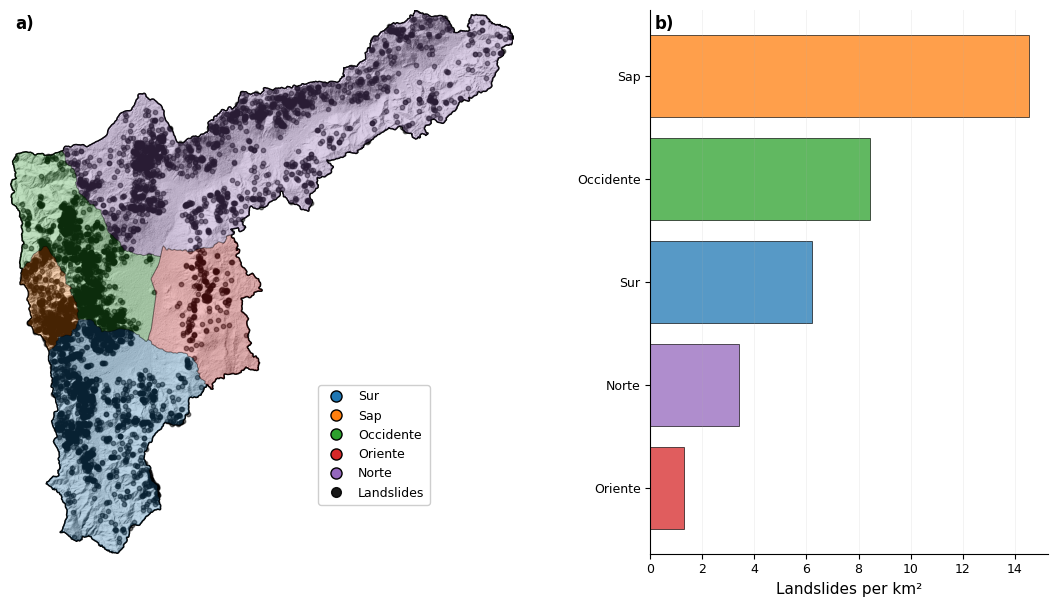

Saved: /home/oisanchezp/Thesis/results/02_Chapter/fig13.png


In [6]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import rasterio as rio
from rasterio.plot import show

from matplotlib.lines import Line2D
from scipy.optimize import linear_sum_assignment  # not used now; keep out

# ─────────────────────────────────────────────
# Global style (same vibe as your map code)
# ─────────────────────────────────────────────
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ─────────────────────────────────────────────
# Paths
# ─────────────────────────────────────────────
dir_data  = "/home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/"
ruta_coor = os.path.join(dir_data, "shape_files")

clusters_path   = "/home/oisanchezp/Geociencias/shape_files/clusters.shp"
study_area_path = "/home/oisanchezp/Thesis/data/metadata/amva.geojson"
path_landslides = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/sensores_remotos_amva.geojson"

out_dir  = "/home/oisanchezp/Thesis/results/02_Chapter"
out_path = os.path.join(out_dir, "fig13.png")
os.makedirs(out_dir, exist_ok=True)

hill_path = os.path.join(ruta_coor, "DEM_west_Hillshade_Clip_r.tif")

# Desired order (Spanish)
ZONE_ORDER_ES = ["Sur", "Sap", "Occidente", "Oriente", "Norte"]

# ─────────────────────────────────────────────
# Load data
# ─────────────────────────────────────────────
gdf_zones = gpd.read_file(clusters_path)          # polygons with column "NOMBRE"
zona_estudio = gpd.read_file(study_area_path)     # study area outline
gdf_ls = gpd.read_file(path_landslides)           # landslides points

hill_src = rio.open(hill_path)
hill = hill_src.read(1)
hill = np.where(hill == hill[0, 0], np.nan, hill)

# ─────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────
def _normalize_zone_name(x):
    """Make zone naming robust (Sap vs SAP vs sap). Keeps your final labels in Spanish."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s_low = s.lower()

    if "sap" in s_low:
        return "Sap"
    if "sur" in s_low:
        return "Sur"
    if "norte" in s_low:
        return "Norte"
    if "oriente" in s_low:
        return "Oriente"
    if "occidente" in s_low:
        return "Occidente"

    # fallback: title-case (still stable-ish)
    return s.title()

def _ensure_crs(gdf, crs):
    if gdf.crs is None:
        return gdf.set_crs(crs)
    return gdf

# ─────────────────────────────────────────────
# 1) Standardize zone names
# ─────────────────────────────────────────────
ZONE_COL = "NOMBRE"
gdf_zones = gdf_zones.copy()
gdf_zones["_zone"] = gdf_zones[ZONE_COL].apply(_normalize_zone_name)

# keep only the zones you want (and order them)
zones_present = gdf_zones["_zone"].dropna().unique().tolist()
zone_order = [z for z in ZONE_ORDER_ES if z in zones_present]
# add any extra zones at end (if appear)
zone_order += [z for z in sorted(zones_present) if z not in zone_order]

# Stable palette by zone (C0..)
palette = [f"C{i}" for i in range(len(zone_order))]
zone_to_color = {z: palette[i] for i, z in enumerate(zone_order)}

# ─────────────────────────────────────────────
# 2) Compute density (#/km²) per zone
#    Use projected CRS for areas + spatial join
# ─────────────────────────────────────────────
CRS_METERS = 3116

zones_m = gdf_zones.to_crs(CRS_METERS).copy()
ls_m = gdf_ls.to_crs(CRS_METERS).copy()

# dissolve polygons by zone
zones_diss = zones_m.dissolve(by="_zone", as_index=False)
zones_diss["area_km2"] = zones_diss.geometry.area / 1e6

# assign each landslide to a zone (within; if missing -> nearest)
j = gpd.sjoin(ls_m[["geometry"]], zones_diss[["_zone", "geometry"]], how="left", predicate="within")
if j["_zone"].isna().any():
    miss = j["_zone"].isna()
    try:
        j_near = gpd.sjoin_nearest(
            ls_m.loc[miss, ["geometry"]],
            zones_diss[["_zone", "geometry"]],
            how="left",
            distance_col="dist_m"
        )
        j.loc[miss, "_zone"] = j_near["_zone"].values
    except Exception:
        # If nearest join isn't available, keep only "within"
        pass

counts = j["_zone"].value_counts(dropna=False).rename("n_landslides").reset_index()
counts = counts.rename(columns={"index": "_zone"})

dens = zones_diss.merge(counts, on="_zone", how="left")
dens["n_landslides"] = dens["n_landslides"].fillna(0).astype(int)
dens["ls_per_km2"] = dens["n_landslides"] / dens["area_km2"]

# order (max to min)
dens_plot = (
    dens.loc[dens["_zone"].isin(zone_order), ["_zone", "ls_per_km2", "n_landslides", "area_km2"]]
    .set_index("_zone")
    .reindex(zone_order)
    .reset_index()
)
dens_plot = dens_plot.sort_values("ls_per_km2", ascending=False)

# ─────────────────────────────────────────────
# 3) Plot: 1×2 (a) map, (b) bars
# ─────────────────────────────────────────────
fig, (ax_map, ax_bar) = plt.subplots(
    1, 2,
    figsize=(11.5, 6.2),
    gridspec_kw={"width_ratios": [1.25, 0.75]}
)

# ---- (a) MAP
show(hill, transform=hill_src.transform, ax=ax_map, cmap="Greys_r")

# plot zones in raster CRS
zones_plot = gdf_zones.to_crs(hill_src.crs).copy()
zones_plot["_zone"] = zones_plot["_zone"].astype(str)
zones_plot["_color"] = zones_plot["_zone"].map(zone_to_color)

# IMPORTANT: avoid NaN colors
zones_plot = zones_plot.dropna(subset=["_color"])

zones_plot.plot(
    ax=ax_map,
    facecolor=zones_plot["_color"],
    edgecolor="black",
    linewidth=0.7,
    alpha=0.28,
    zorder=4
)

# study area outline
zona_estudio = _ensure_crs(zona_estudio, zones_plot.crs).to_crs(hill_src.crs)
zona_estudio.plot(ax=ax_map, facecolor="none", edgecolor="black", linewidth=1.2, zorder=3)

# landslides points (black, 50% alpha)
ls_plot = _ensure_crs(gdf_ls, zones_plot.crs).to_crs(hill_src.crs)
ls_plot.plot(
    ax=ax_map,
    color="black",
    alpha=0.5,
    markersize=10,
    zorder=1
)

# legend: zones + landslides
handles = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=zone_to_color[z], markeredgecolor="black",
           markersize=8, label=z)
    for z in zone_order if z in zone_to_color
]
handles.append(
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="black", markeredgecolor="black",
           alpha=0.9, markersize=7, label="Landslides")
)

ax_map.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(0.6, 0.2),  # push to the right inside panel a)
    frameon=True,
    framealpha=0.95
)

ax_map.set_axis_off()
ax_map.text(0.01, 0.99, "a)", transform=ax_map.transAxes,
            ha="left", va="top", fontweight="bold", fontsize=12)

# ---- (b) BAR PLOT (density)
# horizontal bars read better in a narrow right panel
# ---- (b) BAR PLOT (density) with zone colors
bar_colors = [zone_to_color.get(z, "0.5") for z in dens_plot["_zone"]]

ax_bar.barh(
    dens_plot["_zone"],
    dens_plot["ls_per_km2"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.75
)

ax_bar.invert_yaxis()  # highest on top
ax_bar.set_xlabel("Landslides per km²")
ax_bar.set_ylabel("")
ax_bar.grid(axis="x", alpha=0.15, linewidth=0.7)
ax_bar.text(0.01, 0.99, "b)", transform=ax_bar.transAxes,
            ha="left", va="top", fontweight="bold", fontsize=12)

# optional: add labels (n) at end of bars
# for y, v, n in zip(dens_plot["_zone"], dens_plot["ls_per_km2"], dens_plot["n_landslides"]):
#     ax_bar.text(v, y, f"  n={n}", va="center", fontsize=9)

plt.tight_layout()
fig.savefig(out_path, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved:", out_path)


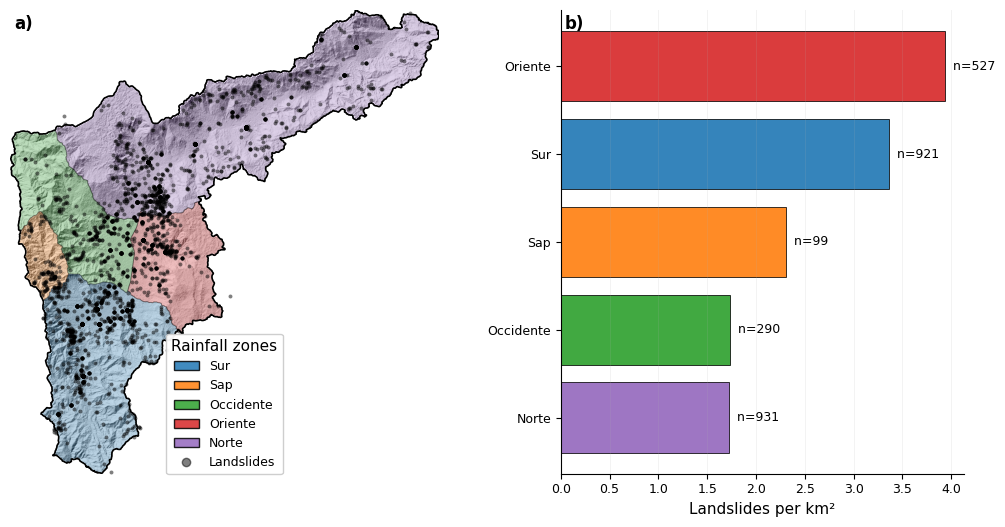

In [7]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import rasterio as rio
from rasterio.plot import show

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from scipy.optimize import linear_sum_assignment

# ─────────────────────────────────────────────
# Landslides (GPKG)  ✅ NEW
# ─────────────────────────────────────────────
path_landslides_gpkg = "/home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/landslides/Geohazard_RS.gpkg"
landslide_layer = "merged"

gdf_ls = gpd.read_file(path_landslides_gpkg, layer=landslide_layer)

# (robusto) si no son puntos, usar un punto representativo para plot/sjoin
if not (gdf_ls.geom_type.isin(["Point", "MultiPoint"]).all()):
    gdf_ls = gdf_ls.copy()
    gdf_ls["geometry"] = gdf_ls.geometry.representative_point()

# limpiar geometrías vacías
gdf_ls = gdf_ls[gdf_ls.geometry.notna()].copy()

# ─────────────────────────────────────────────
# Helpers (los mismos de tu script)
# ─────────────────────────────────────────────
def align_clusters_to_zones(gdf_pts, gdf_polys, zone_col="NOMBRE", target_crs=3116):
    pts_m = gdf_pts.to_crs(target_crs) if (gdf_pts.crs is not None) else gdf_pts.copy()
    polys_m = gdf_polys.to_crs(target_crs) if (gdf_polys.crs is not None) else gdf_polys.copy()

    j = gpd.sjoin(
        pts_m[["cluster_opt", "geometry"]],
        polys_m[[zone_col, "geometry"]],
        how="left",
        predicate="within",
    )

    missing = j[zone_col].isna()
    if missing.any():
        j_miss = gpd.sjoin_nearest(
            pts_m.loc[missing, ["cluster_opt", "geometry"]],
            polys_m[[zone_col, "geometry"]],
            how="left",
            distance_col="dist_m",
        )
        j.loc[missing, zone_col] = j_miss[zone_col].values

    counts = pd.crosstab(j["cluster_opt"], j[zone_col])
    cluster_ids = counts.index.to_list()
    zone_names = counts.columns.to_list()

    cost = -counts.values
    r, c = linear_sum_assignment(cost)
    return {cluster_ids[i]: zone_names[j] for i, j in zip(r, c)}, zone_names


def plot_map_and_density(
    gdf_polys,
    gdf_ls_points,
    hill,
    hill_transform,
    zona_estudio=None,
    zone_col="NOMBRE",
    zone_order=None,
    alpha_poly=0.28,
    lw_poly=0.7,
    dpi=300,
    out_path=None,
    show_fig=True
):
    # ---- orden de zonas y colores estables
    if zone_order is None:
        zone_order = sorted(gdf_polys[zone_col].dropna().unique().tolist())
    palette = [f"C{i}" for i in range(len(zone_order))]
    zone_to_color = {z: palette[i] for i, z in enumerate(zone_order)}

    # ---- CRS comunes
    polys = gdf_polys.copy()
    if polys.crs != gdf_ls_points.crs:
        polys = polys.to_crs(gdf_ls_points.crs)

    if zona_estudio is not None and zona_estudio.crs != gdf_ls_points.crs:
        zona_estudio = zona_estudio.to_crs(gdf_ls_points.crs)

    # ---- asignar zona a cada deslizamiento (within; si falta, nearest)
    ls = gdf_ls_points.copy()
    ls_m = ls.to_crs(3116) if (ls.crs is not None and getattr(ls.crs, "is_geographic", False)) else ls.to_crs(3116)
    polys_m = polys.to_crs(3116)

    j = gpd.sjoin(ls_m[["geometry"]], polys_m[[zone_col, "geometry"]], how="left", predicate="within")
    if j[zone_col].isna().any():
        miss = j[zone_col].isna()
        j2 = gpd.sjoin_nearest(ls_m.loc[miss, ["geometry"]], polys_m[[zone_col, "geometry"]], how="left")
        j.loc[miss, zone_col] = j2[zone_col].values

    ls["_zone"] = j[zone_col].values

    # ---- densidad = N / km2 por zona (área en CRS metros)
    areas_km2 = (polys_m.set_index(zone_col).geometry.area / 1e6).reindex(zone_order)
    counts = ls["_zone"].value_counts().reindex(zone_order).fillna(0).astype(int)
    dens = (counts / areas_km2).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    dens_plot = (
        pd.DataFrame({"_zone": dens.index, "ls_per_km2": dens.values, "n_landslides": counts.values})
        .sort_values("ls_per_km2", ascending=False)
        .reset_index(drop=True)
    )

    # ─────────────────────────────────────────────
    # FIGURA 1x2  (a) mapa  +  (b) barras
    # ─────────────────────────────────────────────
    fig, (ax_map, ax_bar) = plt.subplots(1, 2, figsize=(10.8, 5.4), gridspec_kw={"width_ratios":[1.15, 0.85]})

    # (a) MAPA
    show(hill, transform=hill_transform, ax=ax_map, cmap="Greys_r")

    polys["_color"] = polys[zone_col].astype(str).map(zone_to_color)
    polys.plot(ax=ax_map, facecolor=polys["_color"], edgecolor="black", linewidth=lw_poly, alpha=alpha_poly, zorder=1)

    if zona_estudio is not None:
        zona_estudio.plot(ax=ax_map, facecolor="none", edgecolor="black", linewidth=1.2, zorder=4)

    # deslizamientos: negros con alpha 0.5
    ls.to_crs(ax_map.projection if hasattr(ax_map, "projection") else polys.crs)  # no-op safe
    ls.plot(ax=ax_map, color="black", alpha=0.5, markersize=8, linewidth=0, zorder=3)

    # sin ejes
    ax_map.set_axis_off()
    ax_map.text(0.01, 0.99, "a)", transform=ax_map.transAxes, ha="left", va="top",
                fontweight="bold", fontsize=12)

    # leyenda: zonas + landslides
    zone_handles = [
        Patch(facecolor=zone_to_color[z], edgecolor="black", label=z, alpha=0.85)
        for z in zone_order
    ]
    ls_handle = Line2D([0],[0], marker="o", color="w", markerfacecolor="black",
                       markeredgecolor="black", markersize=6, label="Landslides", alpha=0.5)

    ax_map.legend(
        handles=zone_handles + [ls_handle],
        title="Rainfall zones",
        loc="center left",
        bbox_to_anchor=(0.35, 0.15),
        frameon=True,
        framealpha=0.95
    )

    # (b) BARRAS con colores por zona ✅
    bar_colors = [zone_to_color.get(z, "0.5") for z in dens_plot["_zone"]]
    ax_bar.barh(
        dens_plot["_zone"],
        dens_plot["ls_per_km2"],
        color=bar_colors,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.9
    )
    ax_bar.invert_yaxis()
    ax_bar.set_xlabel("Landslides per km²")
    ax_bar.set_ylabel("")
    ax_bar.grid(axis="x", alpha=0.15, linewidth=0.7)
    ax_bar.text(0.01, 0.99, "b)", transform=ax_bar.transAxes, ha="left", va="top",
                fontweight="bold", fontsize=12)

    # opcional: n sobre cada barra
    for y, v, n in zip(dens_plot["_zone"], dens_plot["ls_per_km2"], dens_plot["n_landslides"]):
        ax_bar.text(v, y, f"  n={n}", va="center", fontsize=9)

    fig.tight_layout()

    if out_path:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight", transparent=True)

    if show_fig:
        plt.show()
    else:
        plt.close(fig)


# ─────────────────────────────────────────────
# Ejemplo de uso (reutiliza tus inputs)
# ─────────────────────────────────────────────
dir_data  = "/home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/"
ruta_coor = os.path.join(dir_data, "shape_files")

clusters_path = "/home/oisanchezp/Geociencias/shape_files/clusters.shp"
study_area_path = "/home/oisanchezp/Thesis/data/metadata/amva.geojson"
out_dir = "/home/oisanchezp/Thesis/results/02_Chapter"
os.makedirs(out_dir, exist_ok=True)

gdf_clusters = gpd.read_file(clusters_path)          # polígonos con NOMBRE
zona_estudio = gpd.read_file(study_area_path)

hill_src = rio.open(os.path.join(ruta_coor, "DEM_west_Hillshade_Clip_r.tif"))
hill = hill_src.read(1)
hill = np.where(hill == hill[0, 0], np.nan, hill)

# orden deseado en español (ajusta si aplica: "Sap" vs "SAP")
ZONE_ORDER_ES = ["Sur", "Sap", "Occidente", "Oriente", "Norte"]

# asegurar CRS común para plot (usa el CRS de polígonos)
if gdf_ls.crs != gdf_clusters.crs:
    gdf_ls = gdf_ls.to_crs(gdf_clusters.crs)

out_path = os.path.join(out_dir, "map_and_density_landslides_GeohazardRS.png")

plot_map_and_density(
    gdf_polys=gdf_clusters,
    gdf_ls_points=gdf_ls,
    hill=hill,
    hill_transform=hill_src.transform,
    zona_estudio=zona_estudio,
    zone_col="NOMBRE",
    zone_order=ZONE_ORDER_ES,
    out_path=out_path,
    dpi=300,
    show_fig=True
)
